In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize
from joblib import Parallel, delayed

import warnings
warnings.filterwarnings('ignore')

In [2]:
TARGET_COL = 'diabetes_label'

# Tier 1: zero-cost (scale + BP cuff, demographics)
FEATURE_COLS_T1 = ['RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'BMXBMI', 'BMXWAIST', 'BPXSY_mean', 'BPXDI_mean']

# Tier 2: adds basic blood panel (requires blood draw)
FEATURE_COLS_T2 = ['LBXTC', 'LBXTR', 'LBXSCR', 'LBXSUA', 'LBXSBU']

# Tier 3: adds full biochemistry panel
FEATURE_COLS_T3 = ['LBXSATSI', 'LBXSASSI', 'LBXSTP', 'LBXSAL', 'LBXSCA', 'LBXSPH', 'LBXSNASI', 'LBXSKSI', 'LBXSGB', 'LBXSC3SI']

ALL_FEATURE_COLS = FEATURE_COLS_T1 + FEATURE_COLS_T2 + FEATURE_COLS_T3

DEFAULT_CONFIG = {
    'learning_rate': 0.1,
    'max_depth': 6,
    'n_estimators': 300,
    'colsample_bytree': 0.75,
    'subsample': 0.8,
}

PARAM_GRID = {
    'n_estimators': [100, 300, 500],
    'max_depth':    [4, 6, 8],
    # 'learning_rate':    [0.01, 0.1, 0.2],
    # 'subsample':        [0.6, 0.8, 1.0],
    # 'colsample_bytree': [0.5, 0.75, 1.0],
}

TEST_SIZE   = 0.2
RANDOM_SEED = 42

In [3]:
def load_data(path):
    df = pd.read_csv(path)
    print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
    print('Label distribution:')
    print(df[TARGET_COL].value_counts().sort_index().rename({0: 'Normal', 1: 'Pre-diabetic', 2: 'Diabetic'}))
    return df


def split_data(df, feature_cols=ALL_FEATURE_COLS):
    X = df[feature_cols].values
    y = df[TARGET_COL].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
    )
    print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
    return X_train, X_test, y_train, y_test


df = load_data('nhanes_diabetes_clean.csv')
X_train, X_test, y_train, y_test = split_data(df)

Loaded: 6045 rows, 30 columns
Label distribution:
diabetes_label
Normal          3659
Pre-diabetic    1635
Diabetic         751
Name: count, dtype: int64
Train: 4836 | Test: 1209


In [4]:
class Model:
    def __init__(self, config=DEFAULT_CONFIG, n_jobs=2):
        self.model = XGBClassifier(
            **config,
            objective='multi:softprob',
            num_class=3,
            random_state=RANDOM_SEED,
            n_jobs=n_jobs,
        )
        self.is_fitted = False
        self.config = config


def train_model(model, X_train, y_train):
    model.model.fit(X_train, y_train)
    model.is_fitted = True
    train_loss = loss(model, X_train, y_train)
    print(f'Train log-loss: {train_loss:.4f}')
    return model


def pred(model, X):
    if not model.is_fitted:
        raise RuntimeError('untrained model')
    return model.model.predict(X)


def pred_proba(model, X):
    if not model.is_fitted:
        raise RuntimeError('untrained model')
    return model.model.predict_proba(X)


def loss(model, X, y):
    proba = pred_proba(model, X)
    eps = 1e-15
    return -np.mean([np.log(proba[i, y[i]] + eps) for i in range(len(y))])


def evaluate(model, X_test, y_test, label='XGBoost'):
    preds  = pred(model, X_test)
    probas = pred_proba(model, X_test)
    f1_mac = f1_score(y_test, preds, average='macro')
    f1_per = f1_score(y_test, preds, average=None)
    y_bin  = label_binarize(y_test, classes=[0, 1, 2])
    auroc  = roc_auc_score(y_bin, probas, multi_class='ovr', average='macro')
    auprc  = average_precision_score(y_bin, probas, average='macro')
    print(f'{label}')
    print(f'  Macro F1:  {f1_mac:.4f}')
    print(f'  F1 per class (Normal / Pre-diab / Diabetic): {f1_per[0]:.3f} / {f1_per[1]:.3f} / {f1_per[2]:.3f}')
    print(f'  AUROC:     {auroc:.4f}')
    print(f'  AUPRC:     {auprc:.4f}')
    return preds, probas, f1_mac, auroc, auprc

In [5]:
xgb_model = Model(config=DEFAULT_CONFIG)
xgb_model = train_model(xgb_model, X_train, y_train)
xgb_preds, xgb_probas, xgb_f1, xgb_auroc, xgb_auprc = evaluate(xgb_model, X_test, y_test, label='XGBoost (all tiers)')

Train log-loss: 0.0970
XGBoost (all tiers)
  Macro F1:  0.5181
  F1 per class (Normal / Pre-diab / Diabetic): 0.806 / 0.427 / 0.321
  AUROC:     0.8041
  AUPRC:     0.5788


In [6]:
def grid_search(X_train, y_train, X_test, y_test, n_jobs=2, top_n=5):
    def train_eval(config):
        model = Model(config=config)
        model.model.fit(X_train, y_train)
        model.is_fitted = True
        val_loss = loss(model, X_test, y_test)
        return {'model': model, 'config': config, 'val_loss': val_loss}

    combos = list(ParameterGrid(PARAM_GRID))
    print(f'Testing {len(combos)} configurations...')

    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(train_eval)(config) for config in combos
    )

    sorted_res = sorted(results, key=lambda x: x['val_loss'])[:top_n]

    print(f'Top {top_n} configurations:')
    for i, r in enumerate(sorted_res):
        print(f'  Rank {i+1} | Loss: {r["val_loss"]:.4f} | Config: {r["config"]}')

    return sorted_res


top  = grid_search(X_train, y_train, X_test, y_test)
best = top[0]['model']

Testing 9 configurations...


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Top 5 configurations:
  Rank 1 | Loss: 0.7263 | Config: {'max_depth': 4, 'n_estimators': 100}
  Rank 2 | Loss: 0.8033 | Config: {'max_depth': 6, 'n_estimators': 100}
  Rank 3 | Loss: 0.8346 | Config: {'max_depth': 4, 'n_estimators': 300}
  Rank 4 | Loss: 0.8598 | Config: {'max_depth': 8, 'n_estimators': 100}
  Rank 5 | Loss: 0.9482 | Config: {'max_depth': 4, 'n_estimators': 500}


[Parallel(n_jobs=2)]: Done   9 out of   9 | elapsed:    6.1s finished


In [7]:
best_preds, best_probas, best_f1, best_auroc, best_auprc = evaluate(best, X_test, y_test, label='XGBoost (best config)')

XGBoost (best config)
  Macro F1:  0.5344
  F1 per class (Normal / Pre-diab / Diabetic): 0.803 / 0.431 / 0.369
  AUROC:     0.8018
  AUPRC:     0.5750


In [8]:
tier_configs = [
    ('Tier 1 (zero-cost)',  FEATURE_COLS_T1),
    ('Tier 1+2 (moderate)', FEATURE_COLS_T1 + FEATURE_COLS_T2),
    ('Tier 1+2+3 (full)',   ALL_FEATURE_COLS),
]

tier_results = []
for tier_label, feature_cols in tier_configs:
    Xtr, Xte, ytr, yte = split_data(df, feature_cols=feature_cols)
    m = Model(config=top[0]['config'])
    m = train_model(m, Xtr, ytr)
    _, _, f1, auroc, auprc = evaluate(m, Xte, yte, label=tier_label)
    tier_results.append({'tier': tier_label, 'f1': f1, 'auroc': auroc, 'auprc': auprc})

Train: 4836 | Test: 1209
Train log-loss: 0.4897
Tier 1 (zero-cost)
  Macro F1:  0.4642
  F1 per class (Normal / Pre-diab / Diabetic): 0.786 / 0.404 / 0.203
  AUROC:     0.7676
  AUPRC:     0.5202
Train: 4836 | Test: 1209
Train log-loss: 0.4243
Tier 1+2 (moderate)
  Macro F1:  0.5295
  F1 per class (Normal / Pre-diab / Diabetic): 0.792 / 0.450 / 0.346
  AUROC:     0.8011
  AUPRC:     0.5612
Train: 4836 | Test: 1209
Train log-loss: 0.3587
Tier 1+2+3 (full)
  Macro F1:  0.5344
  F1 per class (Normal / Pre-diab / Diabetic): 0.803 / 0.431 / 0.369
  AUROC:     0.8018
  AUPRC:     0.5750


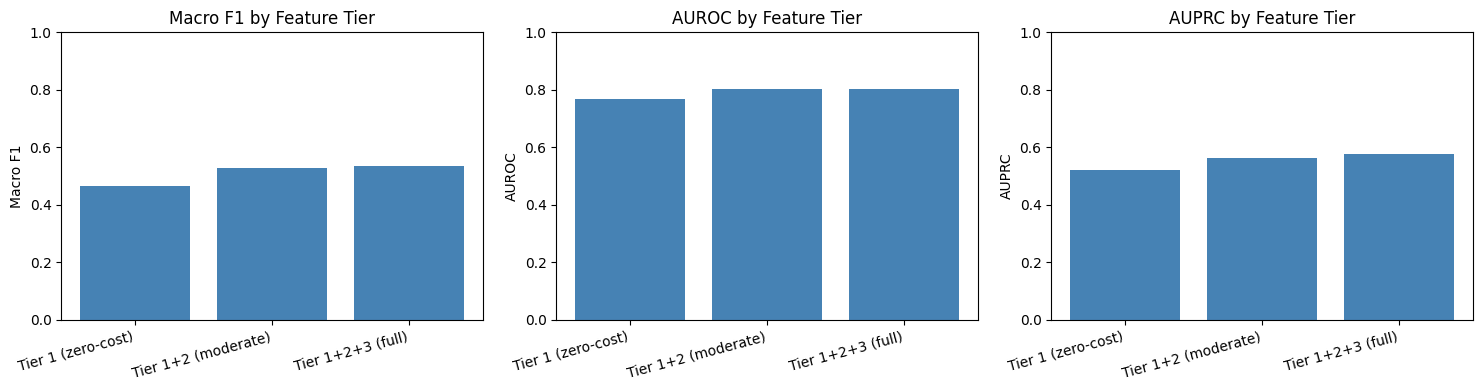

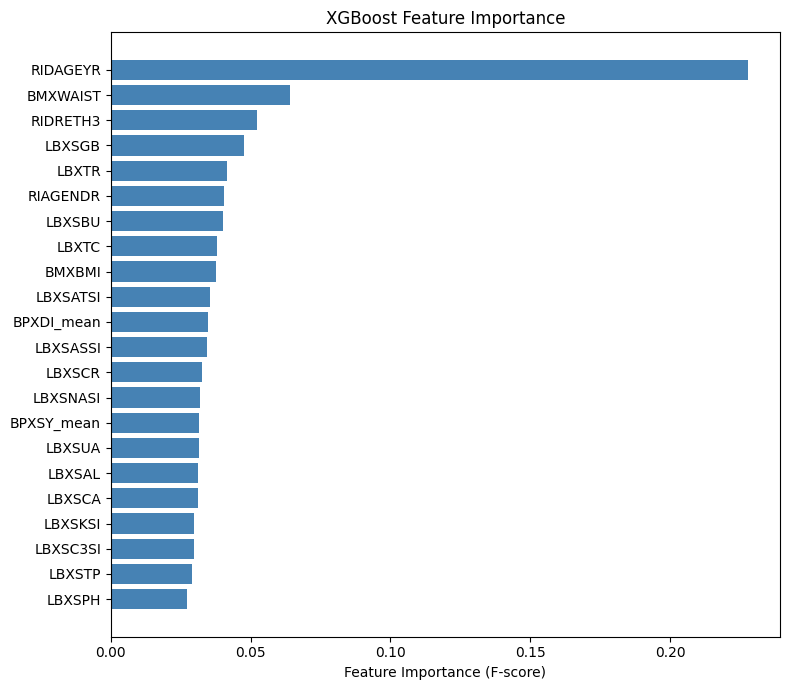

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

tier_labels = [r['tier'] for r in tier_results]
f1s    = [r['f1']    for r in tier_results]
aurocs = [r['auroc'] for r in tier_results]
auprcs = [r['auprc'] for r in tier_results]

for ax, vals, metric in zip(axes, [f1s, aurocs, auprcs], ['Macro F1', 'AUROC', 'AUPRC']):
    ax.bar(range(len(tier_labels)), vals, color='steelblue')
    ax.set_xticks(range(len(tier_labels)))
    ax.set_xticklabels(tier_labels, rotation=15, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Feature Tier')
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('diabetes_tier_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

importances = best.model.feature_importances_
indices     = np.argsort(importances)[::-1]
sorted_features    = [ALL_FEATURE_COLS[i] for i in indices]
sorted_importances = importances[indices]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue')
ax.set_xlabel('Feature Importance (F-score)')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('diabetes_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
_, df_test = train_test_split(
    df.reset_index(drop=True),
    test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=df[TARGET_COL]
)
df_test = df_test.copy()
df_test['pred_label'] = best_preds

def ablation_report(df, split_col, split_labels, title):
    print(f'Ablation: {title}')
    for val, label in split_labels.items():
        subset = df[df[split_col] == val]
        f1 = f1_score(subset[TARGET_COL], subset['pred_label'], average='macro', zero_division=0)
        print(f'  {label:20s} | n={len(subset):5d} | Macro F1: {f1:.3f}')

df_test['age_group'] = pd.cut(df_test['RIDAGEYR'], bins=[18, 40, 60, 100], labels=['18-40', '40-60', '60+'])
print('Ablation: Age group')
for grp in ['18-40', '40-60', '60+']:
    subset = df_test[df_test['age_group'] == grp]
    f1 = f1_score(subset[TARGET_COL], subset['pred_label'], average='macro', zero_division=0)
    print(f'  {grp:20s} | n={len(subset):5d} | Macro F1: {f1:.3f}')

ablation_report(df_test, 'RIAGENDR', {1: 'Male', 2: 'Female'}, 'Sex')

Ablation: Age group
  18-40                | n=  344 | Macro F1: 0.439
  40-60                | n=  328 | Macro F1: 0.479
  60+                  | n=  359 | Macro F1: 0.464
Ablation: Sex
  Male                 | n=  587 | Macro F1: 0.522
  Female               | n=  622 | Macro F1: 0.546


In [ ]:

print(f'XGBoost (default) | F1: {xgb_f1:.4f} | AUROC: {xgb_auroc:.4f} | AUPRC: {xgb_auprc:.4f}')
print(f'XGBoost (tuned)   | F1: {best_f1:.4f} | AUROC: {best_auroc:.4f} | AUPRC: {best_auprc:.4f}')
print(f'\nBest config: {top[0]["config"]}')

RESULTS SUMMARY
XGBoost (default) | F1: 0.5181 | AUROC: 0.8041 | AUPRC: 0.5788
XGBoost (tuned)   | F1: 0.5344 | AUROC: 0.8018 | AUPRC: 0.5750

Best config: {'max_depth': 4, 'n_estimators': 100}
